<a href="https://colab.research.google.com/github/kireykale/Broadway-Project/blob/master/food_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!kaggle datasets download -d l33tc0d3r/indian-food-classification

Dataset URL: https://www.kaggle.com/datasets/l33tc0d3r/indian-food-classification
License(s): MIT
100% 1.48G/1.48G [00:14<00:00, 109MB/s]



In [ ]:
!rm -rf /content/Indian Food

In [ ]:
!unzip indian-food-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: Food Classification/chapati/253.jpg  
  inflating: Food Classification/chapati/254.jpg  
  inflating: Food Classification/chapati/255.jpg  
  inflating: Food Classification/chapati/256.jpg  
  inflating: Food Classification/chapati/257.jpg  
  inflating: Food Classification/chapati/258.jpg  
  inflating: Food Classification/chapati/259.jpg  
  inflating: Food Classification/chapati/260.jpg  
  inflating: Food Classification/chapati/261.jpg  
  inflating: Food Classification/chapati/262.jpg  
  inflating: Food Classification/chapati/263.jpg  
  inflating: Food Classification/chapati/264.jpg  
  inflating: Food Classification/chapati/265.jpg  
  inflating: Food Classification/chapati/266.jpg  
  inflating: Food Classification/chapati/267.jpg  
  inflating: Food Classification/chapati/268.jpg  
  inflating: Food Classification/chapati/269.jpg  
  inflating: Food Classification/chapati/270.jpg  
  inflating: Food Classificatio

Import Essentials

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
image_dir = Path('/content/Food Classification')

In [ ]:
filepaths = list(image_dir.glob(r'**/*.jpg'))

In [ ]:
os.path.split(os.path.split(filepaths[0])[0])[1]

'kulfi'

In [ ]:
labels = list(map(lambda x:os.path.split(os.path.split(x)[0])[1], filepaths))

In [ ]:
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name="Label")

image_df =pd.concat([filepaths,labels], axis=1)

In [ ]:
image_df

,Filepath,Label
0,/content/Food Classification/kulfi/104.jpg,kulfi
1,/content/Food Classification/kulfi/166.jpg,kulfi
2,/content/Food Classification/kulfi/046.jpg,kulfi
3,/content/Food Classification/kulfi/182.jpg,kulfi
4,/content/Food Classification/kulfi/013.jpg,kulfi
...,...,...
6248,/content/Food Classification/dhokla/129.jpg,dhokla
6249,/content/Food Classification/dhokla/246.jpg,dhokla
6250,/content/Food Classification/dhokla/253.jpg,dhokla
6251,/content/Food Classification/dhokla/018.jpg,dhokla


In [ ]:
print(f'Column Names: {labels.unique()}')
print(f'\n\nNumber of Images for each Item: {labels.value_counts()}')

Column Names: ['kulfi' 'burger' 'paani_puri' 'chole_bhature' 'pakode' 'chai' 'momos'
 'masala_dosa' 'dal_makhani' 'fried_rice' 'kaathi_rolls' 'samosa'
 'chapati' 'pav_bhaji' 'kadai_paneer' 'pizza' 'butter_naan' 'jalebi'
 'idli' 'dhokla']


Number of Images for each Item: Label
chapati          413
kadai_paneer     412
chole_bhature    410
chai             381
pav_bhaji        353
fried_rice       353
butter_naan      328
dal_makhani      319
momos            319
masala_dosa      311
burger           309
idli             306
kaathi_rolls     293
jalebi           293
dhokla           289
pakode           278
samosa           261
pizza            261
kulfi            234
paani_puri       130
Name: count, dtype: int64


Train Test Split

In [ ]:
train_df, test_df = train_test_split(image_df, train_size=0.7, shuffle=True, random_state=1)

Create Generators

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split = 0.2
)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 3502 validated image filenames belonging to 20 classes.
Found 875 validated image filenames belonging to 20 classes.
Found 1876 validated image filenames belonging to 20 classes.


Modeling

In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top = False,
    weights = 'imagenet',
    pooling = 'avg'
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = pretrained_model.input

X = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
X = tf.keras.layers.Dense(128, activation='relu')(X)
outputs = tf.keras.layers.Dense(20, activation='softmax')(X)

model = tf.keras.Model(inputs,outputs)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,441,044 (9.31 MB)

 Trainable params: 183,060 (715.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


Training

In [ ]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'],
)
history = model.fit(
    train_images,
    validation_data = val_images,
    epochs = 20,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor = 'val_loss',
            patience = 3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 120s 910ms/step - accuracy: 0.5999 - loss: 1.4238 - val_accuracy: 0.7829 - val_loss: 0.7726
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 67s 610ms/step - accuracy: 0.8361 - loss: 0.5747 - val_accuracy: 0.7817 - val_loss: 0.7856
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 598ms/step - accuracy: 0.8963 - loss: 0.3614 - val_accuracy: 0.7920 - val_loss: 0.7389
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 594ms/step - accuracy: 0.9332 - loss: 0.2398 - val_accuracy: 0.8286 - val_loss: 0.6920
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 72s 660ms/step - accuracy: 0.9615 - loss: 0.1516 - val_accuracy: 0.8091 - val_loss: 0.7048
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 595ms/step - accuracy: 0.9829 - loss: 0.0844 - val_accuracy: 0.8046 - val_loss: 0.7449
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 600ms/step - accuracy: 0.9957 - loss: 0.0457 - val_accuracy: 0.8171 - val_loss: 0.7627


In [ ]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'],
)
history = model.fit(
    train_images,
    validation_data = val_images,
    epochs = 50,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor = 'val_loss',
            patience = 3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 90s 736ms/step - accuracy: 0.9375 - loss: 0.2050 - val_accuracy: 0.8149 - val_loss: 0.7243
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 72s 656ms/step - accuracy: 0.9760 - loss: 0.0992 - val_accuracy: 0.8000 - val_loss: 0.8491
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 591ms/step - accuracy: 0.9860 - loss: 0.0631 - val_accuracy: 0.8057 - val_loss: 0.8613
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 72s 654ms/step - accuracy: 0.9951 - loss: 0.0325 - val_accuracy: 0.8023 - val_loss: 0.8525


Results

In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1]*100))

Test Accuracy: 80.49%


In [ ]:
predictions = np.argmax(model.predict(test_images),axis=1)

cm = confusion_matrix(test_images.labels, predictions)
clr = classification_report(test_images.labels, predictions)

59/59 ━━━━━━━━━━━━━━━━━━━━ 29s 472ms/step


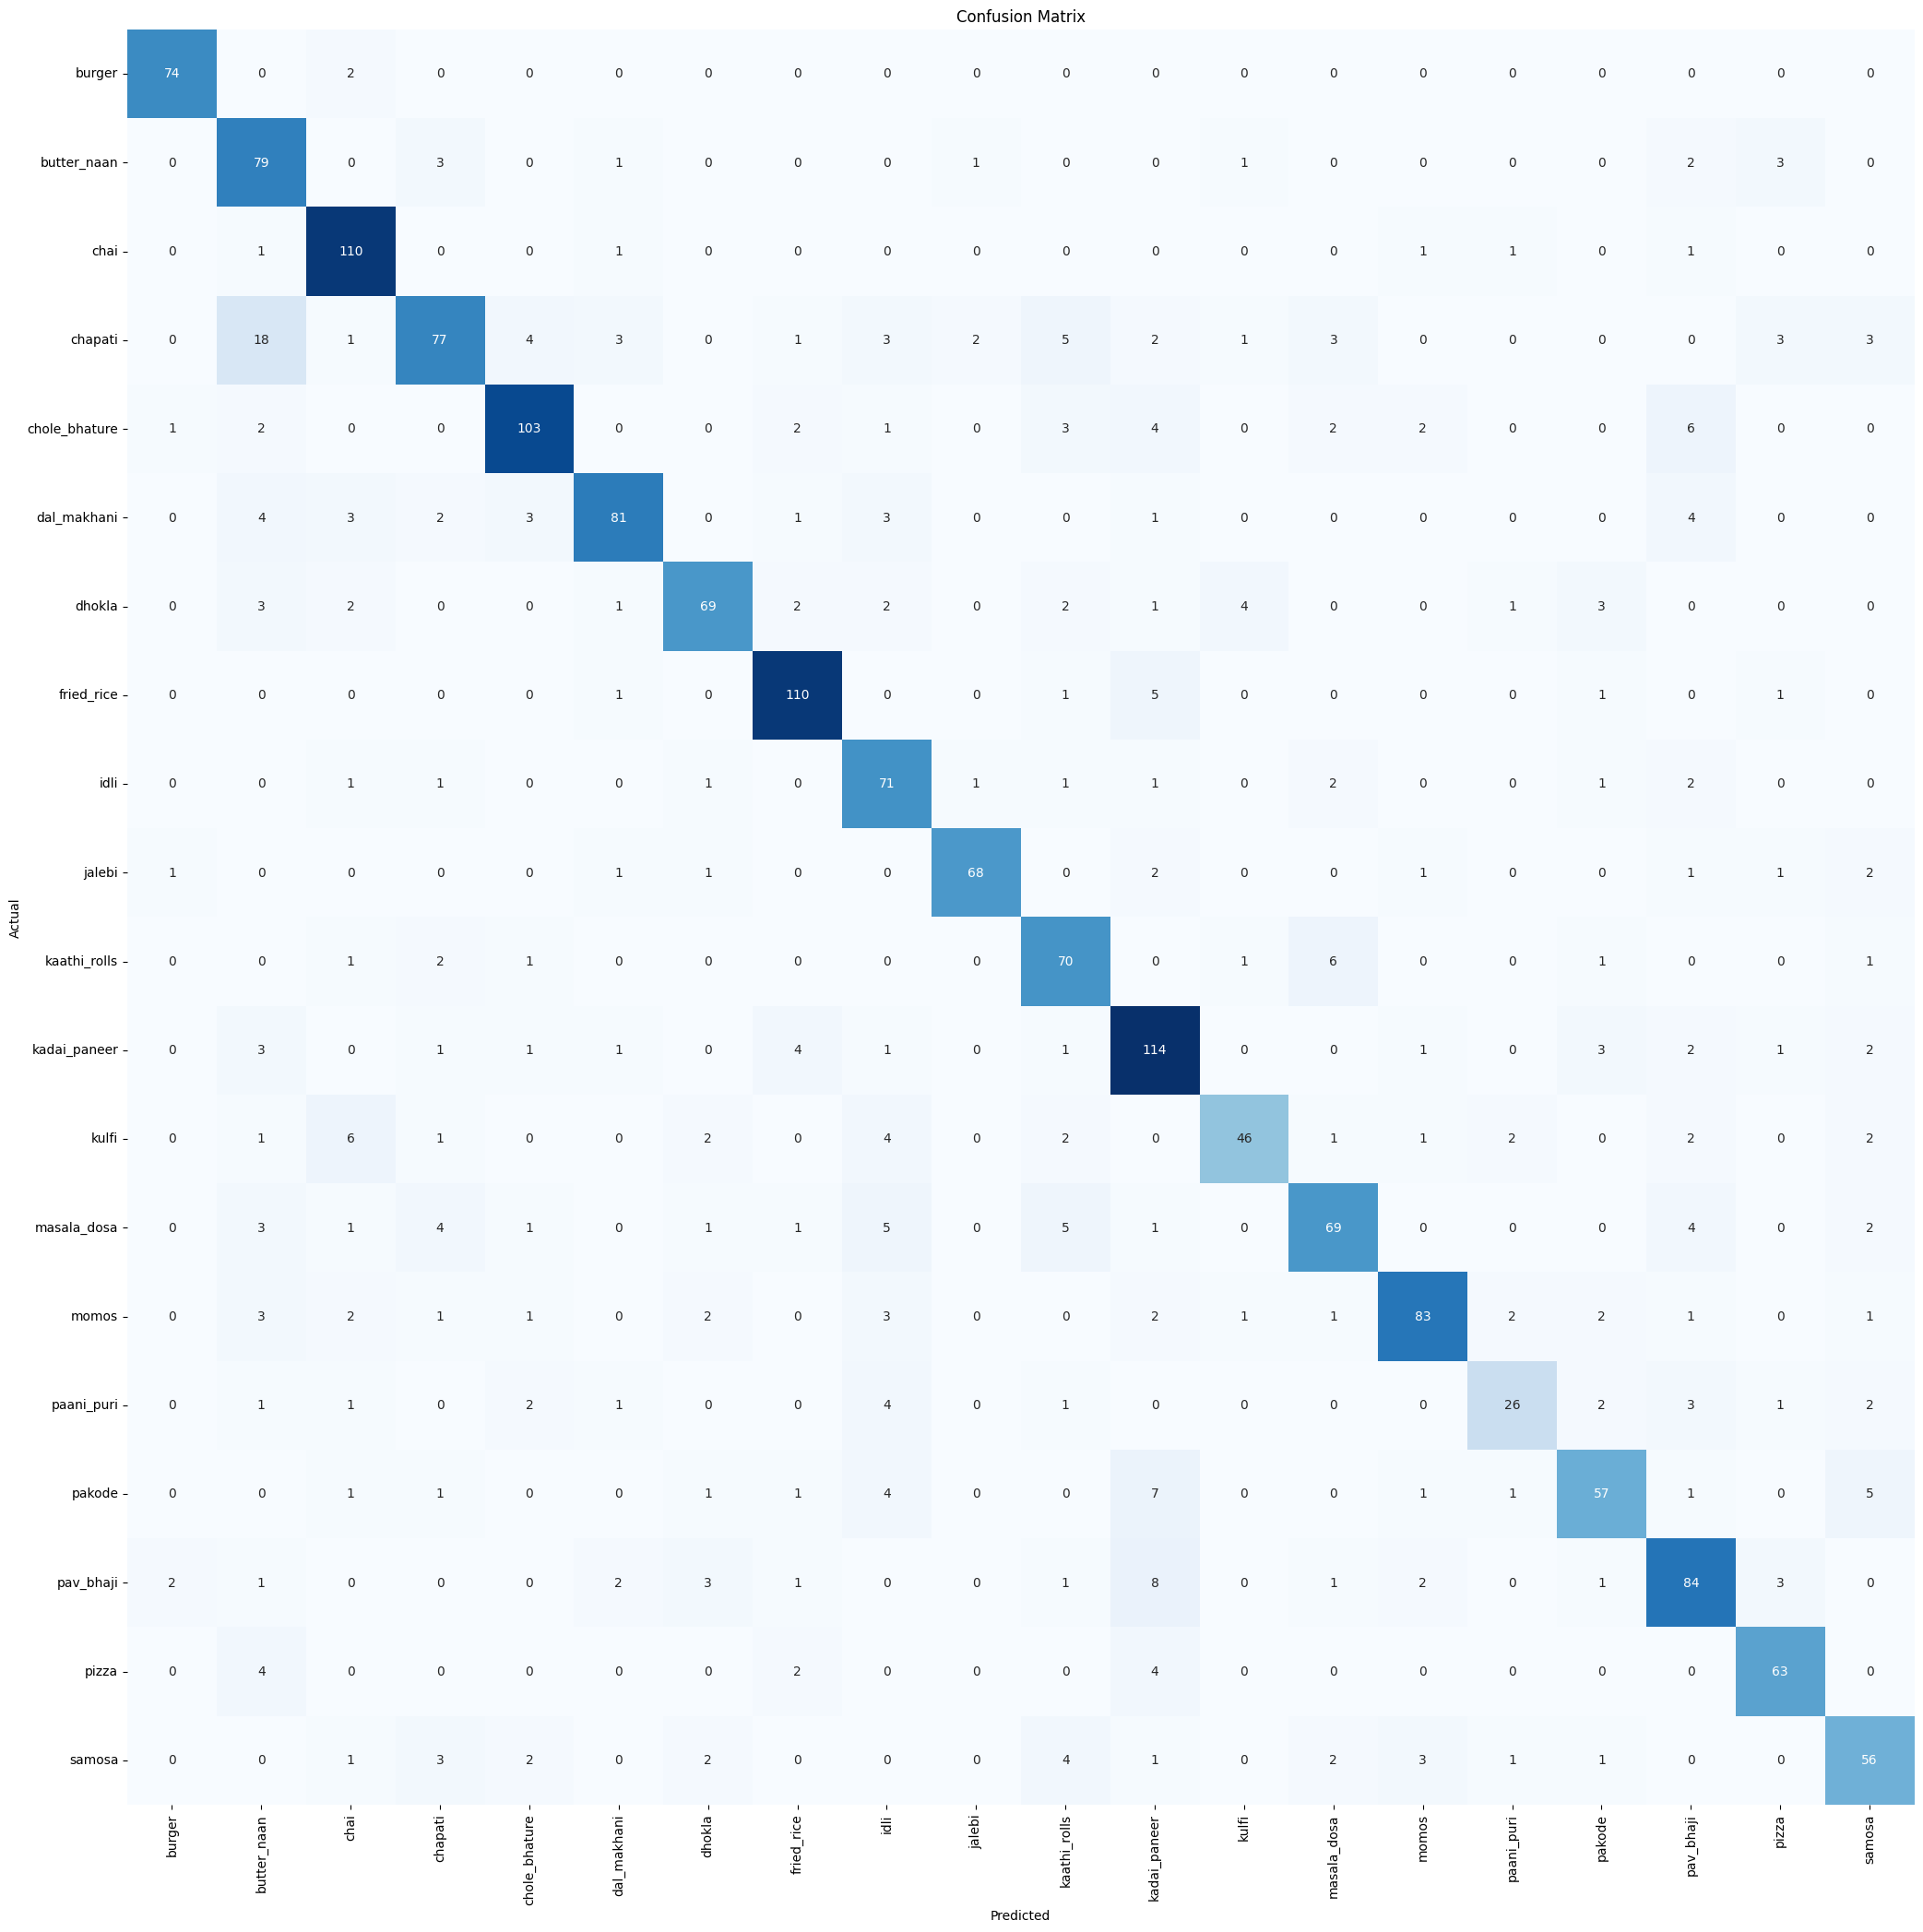

In [ ]:
plt.figure(figsize=(25,25))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
plt.xticks(ticks=np.arange(20)+ 0.5, labels = test_images.class_indices, rotation=90 )
plt.yticks(ticks=np.arange(20)+ 0.5, labels = test_images.class_indices,rotation=0 )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("Classification Score: \n------------------------\n", clr)

Classification Score: 
------------------------
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        76
           1       0.64      0.88      0.74        90
           2       0.83      0.96      0.89       115
           3       0.80      0.61      0.69       126
           4       0.87      0.82      0.84       126
           5       0.87      0.79      0.83       102
           6       0.84      0.77      0.80        90
           7       0.88      0.92      0.90       119
           8       0.70      0.87      0.78        82
           9       0.94      0.87      0.91        78
          10       0.73      0.84      0.78        83
          11       0.75      0.84      0.79       135
          12       0.85      0.66      0.74        70
          13       0.79      0.71      0.75        97
          14       0.87      0.79      0.83       105
          15       0.76      0.59      0.67        44
          16       0.79      0.7

In [ ]:
def predict_with_threshold(model, images, class_indices, threshold=0.3):
    kulfi_idx = class_indices['kulfi']
    predictions = model.predict(images)

    pred_classes = []
    for pred in predictions:
        pred[kulfi_idx] = 0  # suppress kulfi
        if pred.max() < threshold:
            pred_classes.append(-1)  # -1 = "unknown"
        else:
            pred_classes.append(np.argmax(pred))

    return pred_classes

In [ ]:
from google.colab import files

uploaded = files.upload()
n = len(uploaded)
cols = 3
rows = (n // cols) + (1 if n % cols != 0 else 0)

plt.figure(figsize=(15, 2 * rows))

for i, (filename, content) in enumerate(uploaded.items()):
    # save to disk
    with open(filename, 'wb') as f:
        f.write(content)

    img = tf.keras.utils.load_img(filename, target_size=(224, 224,3))
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
    predictions = model.predict(img_array, verbose=0)
    predicted_class = pred_classes[tf.argmax(predictions[0]).numpy()]
    confidence = round(tf.reduce_max(predictions[0]).numpy() * 100, 2)

    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

Saving Screenshot 2026-05-18 225444.png to Screenshot 2026-05-18 225444 (3).png
Saving Screenshot 2026-05-18 225422.png to Screenshot 2026-05-18 225422 (3).png
Saving Screenshot 2026-05-18 225338.png to Screenshot 2026-05-18 225338 (2).png


NameError: name 'pred_classes' is not defined

<Figure size 1500x200 with 0 Axes>

Label
chapati          287
chole_bhature    284
kadai_paneer     277
chai             266
pav_bhaji        244
butter_naan      238
fried_rice       234
burger           233
idli             224
dal_makhani      217
jalebi           215
masala_dosa      214
momos            214
kaathi_rolls     210
dhokla           199
pakode           198
pizza            188
samosa           185
kulfi            164
paani_puri        86
Name: count, dtype: int64


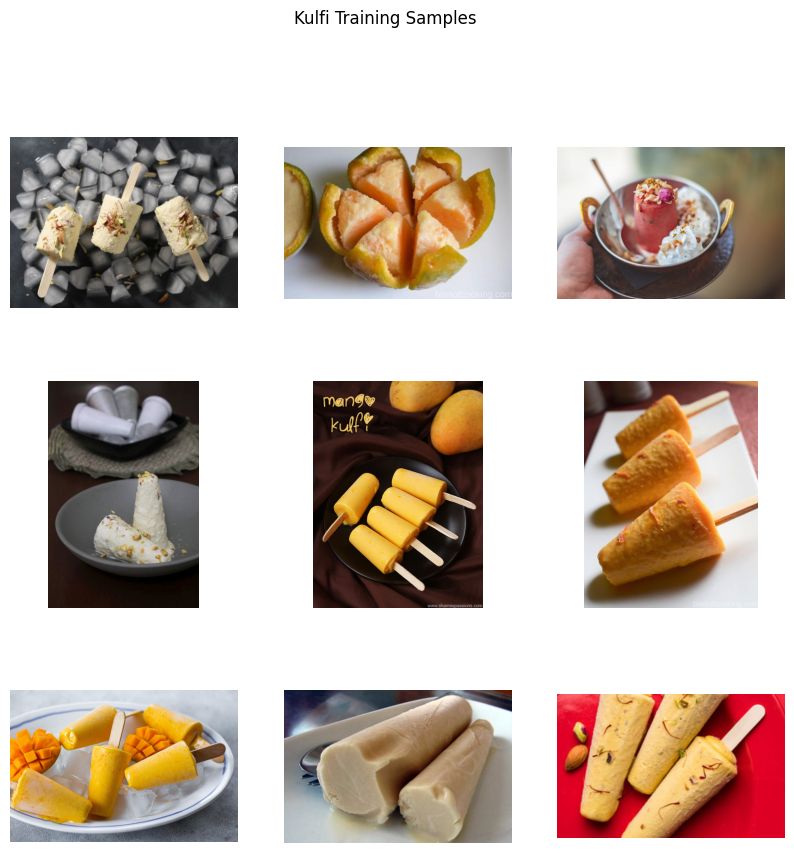

In [ ]:
# See how many samples per class
print(train_df['Label'].value_counts())

# Visualize some kulfi training images
kulfi_df = train_df[train_df['Label'] == 'kulfi'].sample(9)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (_, row) in zip(axes.flatten(), kulfi_df.iterrows()):
    img = plt.imread(row['Filepath'])
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Kulfi Training Samples')
plt.show()